## **Topic Modeling using BERTopic for NYT news**

# Import data from each decade

In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
import pandas as pd

df_8089 = pd.read_csv('1980_1989.csv', usecols=range(12))
df_9099 = pd.read_csv('1990_1999.csv', usecols=range(12))
df_0009 = pd.read_csv('2000_2009.csv', usecols=range(12))
df_1019 = pd.read_csv('2010_2019.csv', usecols=range(12))
df_2024 = pd.read_csv('2020_2024.csv', usecols=range(12))

In [ ]:
# run df for Tu
import pandas as pd

# filter for each decade
df_8089 = pd.read_csv('/content/1980_1989.csv', usecols = range(12))
df_9099 = pd.read_csv('/content/1990_1999.csv', usecols = range(12))
df_0009 = pd.read_csv('/content/2000_2009.csv', usecols = range(12))
df_1019 = pd.read_csv('/content/2010_2019.csv', usecols = range(12))
df_2024 = pd.read_csv('/content/2020_2024.csv', usecols = range(12))

/tmp/ipykernel_12035/427097175.py:6: DtypeWarning: Columns (5,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df_9099 = pd.read_csv('/content/1990_1999.csv', usecols = range(12))
/tmp/ipykernel_12035/427097175.py:7: DtypeWarning: Columns (5,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df_0009 = pd.read_csv('/content/2000_2009.csv', usecols = range(12))


In [ ]:

# 1. List the DataFrames
dfs = [df_8089, df_9099, df_0009, df_1019, df_2024]

# 2. Concatenate them vertically (rows stacked on top of each other)
# ignore_index=True ensures the final DataFrame has a clean 0 to n-1 index
df = pd.concat(dfs, ignore_index=True)


In [ ]:
df

,pub_date,headline,abstract,section_name,print_section,print_page,news_desk,type_of_material,web_url,_id,year,decade
0,1987-02-01 05:00:00+00:00,"L.I.R.R., BACK IN SERVICE, BRACES FOR RETURN O...",LEAD: With a certainty and assurance that hid ...,New York,1,1,Metropolitan Desk,News,https://www.nytimes.com/1987/02/01/nyregion/li...,nyt://article/04a23526-3634-506a-9578-a87b4417...,1987,1980_1989
1,1987-02-01 05:00:00+00:00,"NATIONAL NOTEBOOK: West Philadelphia, Pa.;\nCa...",LEAD: WHEN the Campbell Soup Company picks a d...,Real Estate,8,1,Real Estate Desk,News,https://www.nytimes.com/1987/02/01/realestate/...,nyt://article/0735c537-5411-5ec8-b9f4-a1cce78a...,1987,1980_1989
2,1987-02-01 05:00:00+00:00,THE BIG BUCKS IN KNEES AND ELBOWS,LEAD: THE Hughston Sports Medicine Hospital he...,Business Day,3,1,Financial Desk,News,https://www.nytimes.com/1987/02/01/business/th...,nyt://article/07968442-e79c-515e-a401-b524146b...,1987,1980_1989
3,1987-02-01 05:00:00+00:00,"IN WINTER, THE 'BLUES' BECOME PERVASIVE","LEAD: LIKE the common cold, depression affects...",New York,11NJ,1,New Jersey Weekly Desk,News,https://www.nytimes.com/1987/02/01/nyregion/in...,nyt://article/0827b8f3-9d77-5dd6-9506-d756c2c0...,1987,1980_1989
4,1987-02-01 05:00:00+00:00,TAX REFORM CUTTING LOANS TO BUSINESSES,LEAD: CONNECTICUT businesses that in the past ...,New York,11CN,1,Connecticut Weekly Desk,News,https://www.nytimes.com/1987/02/01/nyregion/ta...,nyt://article/18f7e5c5-b324-5cea-b0fa-1fc220dd...,1987,1980_1989
...,...,...,...,...,...,...,...,...,...,...,...,...
378451,2022-10-30 22:38:55+00:00,Can Elon Musk Make the Math Work on Owning Twi...,Mr. Musk faces financial challenges in owning ...,Technology,B,1,Business,News,https://www.nytimes.com/2022/10/30/technology/...,nyt://article/7d140690-aa9f-5639-b3f7-87a0a071...,2022,2020_2024
378452,2022-10-30 23:31:54+00:00,"Pelosi, Vilified by Republicans for Years, Is ...",The attack on the husband of Speaker Nancy Pel...,U.S.,A,1,Washington,News,https://www.nytimes.com/2022/10/30/us/politics...,nyt://article/365d6966-48aa-595c-8bd4-fa16e656...,2022,2020_2024
378453,2022-10-31 03:30:22+00:00,Brazil Ejects Bolsonaro and Brings Back Leftis...,"Brazilians voted out their far-right leader, J...",World,A,1,Foreign,News,https://www.nytimes.com/2022/10/30/world/ameri...,nyt://article/40a5c544-f659-5afa-881d-742f436b...,2022,2020_2024
378454,2022-10-31 07:00:14+00:00,"Senate Control Hinges on Neck-and-Neck Races, ...","The contests are close in Arizona, Georgia, Ne...",U.S.,A,1,Politics,News,https://www.nytimes.com/2022/10/31/us/politics...,nyt://article/66b26a3f-bda0-5a5d-9720-8dd1a1cc...,2022,2020_2024


# Check data distribution

In [ ]:
df = df.dropna(subset=['abstract'])
df.shape[0]

377381

In [ ]:
parsed = pd.to_datetime(df["pub_date"], errors="coerce")
df = df[~parsed.isna()].copy()

In [ ]:
df

,pub_date,headline,abstract,section_name,print_section,print_page,news_desk,type_of_material,web_url,_id,year,decade
0,1987-02-01 05:00:00+00:00,"L.I.R.R., BACK IN SERVICE, BRACES FOR RETURN O...",LEAD: With a certainty and assurance that hid ...,New York,1,1,Metropolitan Desk,News,https://www.nytimes.com/1987/02/01/nyregion/li...,nyt://article/04a23526-3634-506a-9578-a87b4417...,1987,1980_1989
1,1987-02-01 05:00:00+00:00,"NATIONAL NOTEBOOK: West Philadelphia, Pa.;\nCa...",LEAD: WHEN the Campbell Soup Company picks a d...,Real Estate,8,1,Real Estate Desk,News,https://www.nytimes.com/1987/02/01/realestate/...,nyt://article/0735c537-5411-5ec8-b9f4-a1cce78a...,1987,1980_1989
2,1987-02-01 05:00:00+00:00,THE BIG BUCKS IN KNEES AND ELBOWS,LEAD: THE Hughston Sports Medicine Hospital he...,Business Day,3,1,Financial Desk,News,https://www.nytimes.com/1987/02/01/business/th...,nyt://article/07968442-e79c-515e-a401-b524146b...,1987,1980_1989
3,1987-02-01 05:00:00+00:00,"IN WINTER, THE 'BLUES' BECOME PERVASIVE","LEAD: LIKE the common cold, depression affects...",New York,11NJ,1,New Jersey Weekly Desk,News,https://www.nytimes.com/1987/02/01/nyregion/in...,nyt://article/0827b8f3-9d77-5dd6-9506-d756c2c0...,1987,1980_1989
4,1987-02-01 05:00:00+00:00,TAX REFORM CUTTING LOANS TO BUSINESSES,LEAD: CONNECTICUT businesses that in the past ...,New York,11CN,1,Connecticut Weekly Desk,News,https://www.nytimes.com/1987/02/01/nyregion/ta...,nyt://article/18f7e5c5-b324-5cea-b0fa-1fc220dd...,1987,1980_1989
...,...,...,...,...,...,...,...,...,...,...,...,...
378449,2022-10-30 22:38:55+00:00,Can Elon Musk Make the Math Work on Owning Twi...,Mr. Musk faces financial challenges in owning ...,Technology,B,1,Business,News,https://www.nytimes.com/2022/10/30/technology/...,nyt://article/7d140690-aa9f-5639-b3f7-87a0a071...,2022,2020_2024
378450,2022-10-30 23:31:54+00:00,"Pelosi, Vilified by Republicans for Years, Is ...",The attack on the husband of Speaker Nancy Pel...,U.S.,A,1,Washington,News,https://www.nytimes.com/2022/10/30/us/politics...,nyt://article/365d6966-48aa-595c-8bd4-fa16e656...,2022,2020_2024
378451,2022-10-31 03:30:22+00:00,Brazil Ejects Bolsonaro and Brings Back Leftis...,"Brazilians voted out their far-right leader, J...",World,A,1,Foreign,News,https://www.nytimes.com/2022/10/30/world/ameri...,nyt://article/40a5c544-f659-5afa-881d-742f436b...,2022,2020_2024
378452,2022-10-31 07:00:14+00:00,"Senate Control Hinges on Neck-and-Neck Races, ...","The contests are close in Arizona, Georgia, Ne...",U.S.,A,1,Politics,News,https://www.nytimes.com/2022/10/31/us/politics...,nyt://article/66b26a3f-bda0-5a5d-9720-8dd1a1cc...,2022,2020_2024


In [ ]:
# count_yearly = df.groupby('year', as_index=False)['abstract'].count()

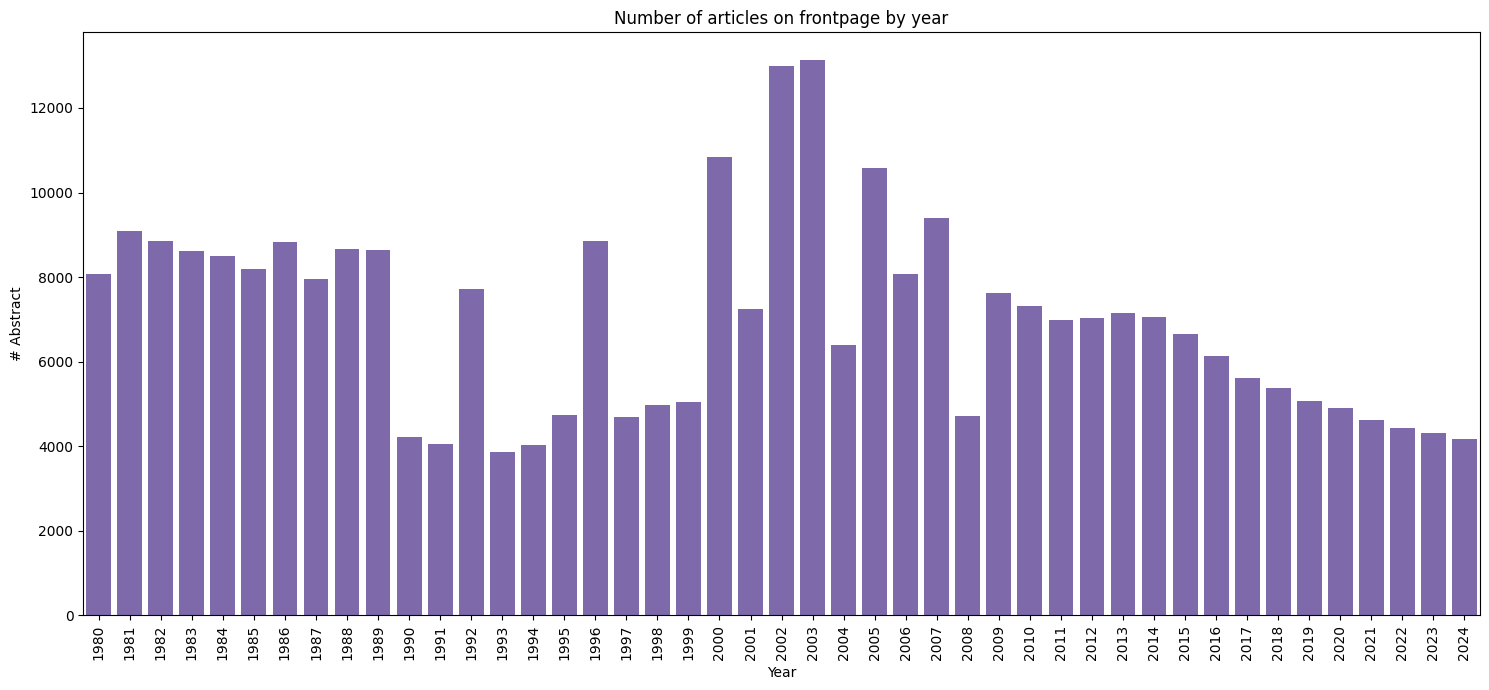

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# plt.figure(figsize=(15, 7))

# sns.barplot(
#     data=count_yearly,
#     x="year",
#     y="abstract",
#     linewidth=2,
#     color = "#7a5eb5",
#     errorbar=None
# )

# plt.title("Number of articles on frontpage by year")
# plt.xlabel("Year")
# plt.ylabel("# Abstract")
# plt.xticks(rotation=90)

# plt.tight_layout()
# plt.show()

# Set up for BERTopic

In [ ]:
!pip install bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 4.7 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import seaborn as sns
import umap
import hdbscan
import nltk

In [ ]:
!pip install umap-learn

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')   # also needed for lemmatizer

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
import re
import random
import numpy as np
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN

# China


In [ ]:
# China - keywords
# create score summing keywords, include anything that is more than 10 mentions.
china = ["china", "chinese", "beijing", "ccp", "mr. xi", "xi jinping", "hong kong"]
china_keywords = "|".join(china)
df['mention_china'] = df['abstract'].str.contains(china_keywords, case=False, na=False)

In [ ]:
# choose subset of data before modeling
df_china = df[df['mention_china']==True]
df_china.shape[0]

7548

In [ ]:
percent_focused = (df[df['mention_china'] == True].shape[0] / df.shape[0])*100
percent_focused

2.0001112939511736

In [ ]:
seed = 42
np.random.seed(seed)
random.seed(seed)

# remove stop words
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r"\d+", "", text)          # remove numbers
    text = re.sub(r"\W+", " ", text)         # remove punctuation
    words = [lemmatizer.lemmatize(w) for w in text.split() if w not in stop_words]
    return ' '.join(words)

newspaper_abstracts = df_china['abstract']
docs_clean = [clean_text(str(doc)) for doc in newspaper_abstracts]

# Initialize model
embed_model = SentenceTransformer("all-MiniLM-L6-v2") # sligtly faster than default

# dimensionality reduction
umap_model = umap.UMAP(n_neighbors=25, min_dist = 0.01, metric='cosine', random_state = 42)

# clustering model (hdbscan or k-means)
clustering_model = hdbscan.HDBSCAN(
    min_cluster_size=15,
    metric='euclidean',
    cluster_selection_method='eom',
    min_samples=5
)

topic_model = BERTopic(
    embedding_model=embed_model,
    hdbscan_model=clustering_model,
    umap_model=umap_model,
    verbose=True
)
topics_model, probs = topic_model.fit_transform(docs_clean)



modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

2026-04-30 15:17:04,869 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/236 [00:00<?, ?it/s]

2026-04-30 15:21:02,999 - BERTopic - Embedding - Completed ✓
2026-04-30 15:21:03,001 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-30 15:22:00,042 - BERTopic - Dimensionality - Completed ✓
2026-04-30 15:22:00,044 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-30 15:22:00,239 - BERTopic - Cluster - Completed ✓
2026-04-30 15:22:00,251 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-30 15:22:00,771 - BERTopic - Representation - Completed ✓


In [ ]:
# @title
# from google.colab import drive
# import os
# import numpy as np

# # Mount Google Drive
# drive.mount('/content/drive')

# # Create folder if it doesn't exist
# save_dir = "/content/drive/MyDrive/bertopic_project"
# os.makedirs(save_dir, exist_ok=True)

# # Save BERTopic model
# topic_model.save(
#     f"{save_dir}/bertopic_model",
#     serialization="safetensors",
#     save_ctfidf=True,
#     save_embedding_model=True
# )

# # Save topics and probabilities
# np.save(f"{save_dir}/topics.npy", topics_model)
# np.save(f"{save_dir}/probs.npy", probs)

# # Save CSV summaries
# topic_model.get_topic_info().to_csv(f"{save_dir}/topic_info.csv", index=False)
# topic_model.get_document_info(docs_clean).to_csv(f"{save_dir}/doc_topics.csv", index=False)

# print(f"All files saved to {save_dir}")

In [ ]:
# Evaluate the model result
topic_model.get_topic_info().head(100).set_index('Topic')[['Count', 'Name', 'Representation']]

,Count,Name,Representation
Topic,,,
-1,2553,-1_china_chinese_american_state,"[china, chinese, american, state, year, trade,..."
0,170,0_bank_loan_debt_lending,"[bank, loan, debt, lending, rate, central, ban..."
1,161,1_editorial_letter_note_around,"[editorial, letter, note, around, sport, art, ..."
2,150,2_car_vehicle_motor_auto,"[car, vehicle, motor, auto, automaker, electri..."
3,135,3_food_restaurant_cooking_cuisine,"[food, restaurant, cooking, cuisine, dish, che..."
...,...,...,...
94,21,94_ibm_pc_lenovo_computer,"[ibm, pc, lenovo, computer, personal, sony, el..."
95,21,95_farmer_sears_trade_furniture,"[farmer, sears, trade, furniture, dairy, cotto..."
96,21,96_mao_zeng_asian_jiang,"[mao, zeng, asian, jiang, leader, terrorism, p..."


In [ ]:
topic_model.visualize_barchart(top_n_topics = 16, n_words = 10)

In [ ]:
df_china['year'] = pd.to_datetime(df_china['pub_date']).dt.year
topic_model.reduce_topics(docs_clean, nr_topics=16)

# Update assignments directly from the model
new_topics = topic_model.topics_
new_probs = topic_model.probabilities_

# Update dataframe
df_china['topic'] = new_topics
df_china['topic_prob'] = [p.max() for p in new_probs]

2026-04-30 15:22:28,342 - BERTopic - Topic reduction - Reducing number of topics
2026-04-30 15:22:28,372 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-30 15:22:28,861 - BERTopic - Representation - Completed ✓
2026-04-30 15:22:28,865 - BERTopic - Topic reduction - Reduced number of topics from 114 to 16


In [ ]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,2553,-1_china_chinese_year_american,"[china, chinese, year, american, state, new, c...",[pres bush expected press china reduce large g...
1,0,1749,0_china_company_chinese_market,"[china, company, chinese, market, percent, ban...",[company controlled mainland china fallen disr...
2,1,1193,1_china_chinese_party_leader,"[china, chinese, party, leader, president, sta...",[united state china agreed today preliminary s...
3,2,381,2_chinatown_new_restaurant_street,"[chinatown, new, restaurant, street, city, chi...",[attitude ranging new york exciting critic lov...
4,3,317,3_north_korea_nuclear_bush,"[north, korea, nuclear, bush, china, say, weap...",[north korea declares publicly first time poss...
5,4,301,4_new_page_said_york,"[new, page, said, york, city, year, company, e...",[cloud athens pollution israel warns consequen...
6,5,219,5_sars_disease_virus_health,"[sars, disease, virus, health, china, drug, ca...",[sars continues investigated despite relative ...
7,6,193,6_art_museum_exhibition_photo,"[art, museum, exhibition, photo, chinese, oper...",[holland cotter review refurbished expanded ga...
8,7,135,7_film_movie_chinese_book,"[film, movie, chinese, book, china, theater, p...",[interview director ang lee new project crouch...
9,8,133,8_olympic_medal_gold_game,"[olympic, medal, gold, game, olympics, beijing...",[li ning china three gold medal one silver ame...


In [ ]:
topic_model.visualize_barchart(top_n_topics = 15, n_words = 10)

In [ ]:
df

,pub_date,headline,abstract,section_name,print_section,print_page,news_desk,type_of_material,web_url,_id,year,decade,mention_china
0,1987-02-01 05:00:00+00:00,"L.I.R.R., BACK IN SERVICE, BRACES FOR RETURN O...",LEAD: With a certainty and assurance that hid ...,New York,1,1,Metropolitan Desk,News,https://www.nytimes.com/1987/02/01/nyregion/li...,nyt://article/04a23526-3634-506a-9578-a87b4417...,1987,1980_1989,False
1,1987-02-01 05:00:00+00:00,"NATIONAL NOTEBOOK: West Philadelphia, Pa.;\nCa...",LEAD: WHEN the Campbell Soup Company picks a d...,Real Estate,8,1,Real Estate Desk,News,https://www.nytimes.com/1987/02/01/realestate/...,nyt://article/0735c537-5411-5ec8-b9f4-a1cce78a...,1987,1980_1989,False
2,1987-02-01 05:00:00+00:00,THE BIG BUCKS IN KNEES AND ELBOWS,LEAD: THE Hughston Sports Medicine Hospital he...,Business Day,3,1,Financial Desk,News,https://www.nytimes.com/1987/02/01/business/th...,nyt://article/07968442-e79c-515e-a401-b524146b...,1987,1980_1989,False
3,1987-02-01 05:00:00+00:00,"IN WINTER, THE 'BLUES' BECOME PERVASIVE","LEAD: LIKE the common cold, depression affects...",New York,11NJ,1,New Jersey Weekly Desk,News,https://www.nytimes.com/1987/02/01/nyregion/in...,nyt://article/0827b8f3-9d77-5dd6-9506-d756c2c0...,1987,1980_1989,False
4,1987-02-01 05:00:00+00:00,TAX REFORM CUTTING LOANS TO BUSINESSES,LEAD: CONNECTICUT businesses that in the past ...,New York,11CN,1,Connecticut Weekly Desk,News,https://www.nytimes.com/1987/02/01/nyregion/ta...,nyt://article/18f7e5c5-b324-5cea-b0fa-1fc220dd...,1987,1980_1989,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
378451,2022-10-30 22:38:55+00:00,Can Elon Musk Make the Math Work on Owning Twi...,Mr. Musk faces financial challenges in owning ...,Technology,B,1,Business,News,https://www.nytimes.com/2022/10/30/technology/...,nyt://article/7d140690-aa9f-5639-b3f7-87a0a071...,2022,2020_2024,False
378452,2022-10-30 23:31:54+00:00,"Pelosi, Vilified by Republicans for Years, Is ...",The attack on the husband of Speaker Nancy Pel...,U.S.,A,1,Washington,News,https://www.nytimes.com/2022/10/30/us/politics...,nyt://article/365d6966-48aa-595c-8bd4-fa16e656...,2022,2020_2024,False
378453,2022-10-31 03:30:22+00:00,Brazil Ejects Bolsonaro and Brings Back Leftis...,"Brazilians voted out their far-right leader, J...",World,A,1,Foreign,News,https://www.nytimes.com/2022/10/30/world/ameri...,nyt://article/40a5c544-f659-5afa-881d-742f436b...,2022,2020_2024,False
378454,2022-10-31 07:00:14+00:00,"Senate Control Hinges on Neck-and-Neck Races, ...","The contests are close in Arizona, Georgia, Ne...",U.S.,A,1,Politics,News,https://www.nytimes.com/2022/10/31/us/politics...,nyt://article/66b26a3f-bda0-5a5d-9720-8dd1a1cc...,2022,2020_2024,False


In [ ]:
# ── China: topics over time ──────────────────────────────
timestamps_china = df_china['year'].tolist()

tot_china = topic_model.topics_over_time(   # topic_model = your China model
    docs_clean,
    timestamps_china,
    nr_bins=None,
    global_tuning=True,
    evolution_tuning=True
)

fig_china = topic_model.visualize_topics_over_time(tot_china, top_n_topics=10)
fig_china.show()
fig_china.write_html("/content/china_topics_over_time.html")

45it [00:20,  2.21it/s]


In [ ]:
df_china[df_china['year']==2024]

,pub_date,headline,abstract,section_name,print_section,print_page,news_desk,type_of_material,web_url,_id,year,decade,mention_china,topic,topic_prob
360243,2024-08-02 04:00:09+00:00,"In Xi’s China, Politics Eventually Catches Up ...",The author Peter Hessler posed a question with...,Business Day,B,1,Business,News,https://www.nytimes.com/2024/08/02/business/ch...,nyt://article/fc6284f7-c327-5d98-9c23-0ec3baee...,2024,2020_2024,True,-1,0.000000
360262,2024-08-04 04:00:20+00:00,"With Smugglers and Front Companies, China Is S...",The U.S. is trying to stop China from getting ...,Technology,A,1,Investigative,News,https://www.nytimes.com/2024/08/04/technology/...,nyt://article/0faa487c-bae7-5325-a119-69b183b3...,2024,2020_2024,True,-1,0.000000
360328,2024-08-09 04:00:16+00:00,How China Built Tech Prowess: Chemistry Classe...,"Stressing science education, China is outpacin...",Business Day,B,1,Business,News,https://www.nytimes.com/2024/08/09/business/ch...,nyt://article/84f2702a-60f6-5c5b-989d-df856824...,2024,2020_2024,True,0,0.617489
360339,2024-08-09 16:26:43+00:00,U.S. Vies With Allies and Industry to Tighten ...,The Biden administration must navigate the int...,Business Day,B,1,Washington,News,https://www.nytimes.com/2024/08/09/business/ec...,nyt://article/876dfabe-b5f6-5983-a12d-48ddd1de...,2024,2020_2024,True,-1,0.000000
360358,2024-08-11 09:04:28+00:00,Tim Walz’s Long Relationship With China Defies...,"Mr. Walz, the Democrats’ vice-presidential nom...",U.S.,A,1,National,News,https://www.nytimes.com/2024/08/11/us/tim-walz...,nyt://article/a95edbe7-0f69-5cb4-a502-87db75dd...,2024,2020_2024,True,1,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
370570,2024-12-19 05:00:13+00:00,G.M. Led in China for Years. Here’s How It End...,General Motors has gone from market leader to ...,Business Day,B,1,Business,News,https://www.nytimes.com/2024/12/19/business/gm...,nyt://article/15588b82-5746-5947-8018-26523701...,2024,2020_2024,True,0,0.978609
370573,2024-12-19 10:00:57+00:00,"As China Seeks Influence, It Has a Cuddly Way ...",Records and interviews show that Beijing has u...,World,A,1,Foreign,News,https://www.nytimes.com/2024/12/19/world/asia/...,nyt://article/6b160c22-8daf-52ce-bcc4-8097dfbf...,2024,2020_2024,True,1,0.697190
370584,2024-12-20 01:12:40+00:00,Macau Is the Casino Capital of the World. For ...,A quarter century after the former Portuguese ...,Business Day,B,1,Business,News,https://www.nytimes.com/2024/12/19/business/ma...,nyt://article/06e77c62-d581-5173-99e0-24f05c7c...,2024,2020_2024,True,1,1.000000
370618,2024-12-23 08:14:35+00:00,Honda and Nissan Aim to Merge as Global Compet...,Japan’s second- and third-largest automakers h...,Business Day,B,1,Business,News,https://www.nytimes.com/2024/12/23/business/ho...,nyt://article/c2c19dfb-c54f-559a-9096-7e8656fa...,2024,2020_2024,True,0,1.000000


# Russia

In [ ]:
# Russia - keywords
russia = ["russia", "russian", "russian federation", "kremlin", "putin", "moscow"]
russia_keywords = "|".join(russia)
df['mention_russia'] = df['abstract'].str.contains(russia_keywords, case=False, na=False)

In [ ]:
# subset Russia articles
df_russia = df[df['mention_russia'] == True].copy()

num_russia = df_russia.shape[0]
percent_russia = (num_russia / df.shape[0]) * 100

print("Number of Russia articles:", num_russia)
print("Percent of dataset:", percent_russia)

Number of Russia articles: 7787
Percent of dataset: 2.063442851881


In [ ]:
import numpy as np
import random
import re
import os

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
import umap
import hdbscan

seed = 42
np.random.seed(seed)
random.seed(seed)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"\W+", " ", text)
    words = [lemmatizer.lemmatize(w) for w in text.split() if w not in stop_words]
    return ' '.join(words)

In [ ]:
docs_clean = [clean_text(str(doc)) for doc in df_russia['abstract']]

In [ ]:
embed_model = SentenceTransformer("all-MiniLM-L6-v2")

umap_model = umap.UMAP(
    n_neighbors=25,
    min_dist=0.01,
    metric='cosine',
    random_state=42
)

clustering_model = hdbscan.HDBSCAN(
    min_cluster_size=15,
    metric='euclidean',
    cluster_selection_method='eom',
    min_samples=5
)

topic_model = BERTopic(
    embedding_model=embed_model,
    hdbscan_model=clustering_model,
    umap_model=umap_model,
    verbose=True
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
topics_model, probs = topic_model.fit_transform(docs_clean)

2026-05-01 01:11:55,651 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/244 [00:00<?, ?it/s]

2026-05-01 01:16:15,069 - BERTopic - Embedding - Completed ✓
2026-05-01 01:16:15,071 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-01 01:16:35,806 - BERTopic - Dimensionality - Completed ✓
2026-05-01 01:16:35,808 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-01 01:16:35,973 - BERTopic - Cluster - Completed ✓
2026-05-01 01:16:35,982 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-01 01:16:36,599 - BERTopic - Representation - Completed ✓


In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
# save_dir = "/content/drive/MyDrive/bertopic_russia"
# os.makedirs(save_dir, exist_ok=True)

In [ ]:
# topic_model.save(
#     f"{save_dir}/bertopic_model",
#     serialization="safetensors",
#     save_ctfidf=True,
#     save_embedding_model=True
# )

In [ ]:
# np.save(f"{save_dir}/topics.npy", topics_model)
# np.save(f"{save_dir}/probs.npy", probs)

In [ ]:
# topic_model.get_topic_info().to_csv(f"{save_dir}/topic_info.csv", index=False)
# topic_model.get_document_info(docs_clean).to_csv(f"{save_dir}/doc_topics.csv", index=False)

# print(f"All files saved to {save_dir}")

In [ ]:
topic_model.get_topic_info().head(100).set_index('Topic')[['Count', 'Name', 'Representation']]

,Count,Name,Representation
Topic,,,
-1,2251,-1_russia_russian_soviet_moscow,"[russia, russian, soviet, moscow, page, presid..."
0,317,0_computing_computer_software_microsoft,"[computing, computer, software, microsoft, per..."
1,302,1_reagan_soviet_meeting_mr,"[reagan, soviet, meeting, mr, said, arm, presi..."
2,203,2_intelligence_espionage_daniloff_spy,"[intelligence, espionage, daniloff, spy, agent..."
3,182,3_trump_investigation_election_donald,"[trump, investigation, election, donald, inter..."
...,...,...,...
94,17,94_theater_directed_play_chekhov,"[theater, directed, play, chekhov, ben, brantl..."
95,17,95_radio_television_station_broadcast,"[radio, television, station, broadcast, progra..."
96,16,96_ntv_gazprom_gusinsky_turner,"[ntv, gazprom, gusinsky, turner, stake, networ..."


In [ ]:
df_russia['year'] = pd.to_datetime(df_russia['pub_date']).dt.year

In [ ]:
topic_model.reduce_topics(docs_clean, nr_topics=15)
new_topics = topic_model.topics_
new_probs = topic_model.probabilities_
df_russia['topic'] = new_topics
df_russia['topic_prob'] = [p.max() for p in new_probs]

2026-05-01 01:16:37,436 - BERTopic - Topic reduction - Reducing number of topics
2026-05-01 01:16:37,465 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-01 01:16:38,024 - BERTopic - Representation - Completed ✓
2026-05-01 01:16:38,030 - BERTopic - Topic reduction - Reduced number of topics from 105 to 15


In [ ]:
topic_model.get_topic_info().head(15).set_index('Topic')[['Count', 'Name', 'Representation']]

,Count,Name,Representation
Topic,,,
-1,2251,-1_russia_russian_soviet_moscow,"[russia, russian, soviet, moscow, state, presi..."
0,2149,0_soviet_president_said_mr,"[soviet, president, said, mr, moscow, state, r..."
1,690,1_russian_intelligence_soviet_official,"[russian, intelligence, soviet, official, russ..."
2,674,2_oil_russia_company_russian,"[oil, russia, company, russian, billion, perce..."
3,317,3_computer_computing_software_company,"[computer, computing, software, company, micro..."
4,278,4_museum_art_photo_ballet,"[museum, art, photo, ballet, new, film, music,..."
5,267,5_chechnya_chechen_russian_plane,"[chechnya, chechen, russian, plane, grozny, re..."
6,261,6_new_page_company_year,"[new, page, company, year, said, york, percent..."
7,208,7_space_station_nuclear_mir,"[space, station, nuclear, mir, russian, accide..."


In [ ]:
topic_model.visualize_barchart(top_n_topics=15, n_words=10)

In [ ]:
# ── Russia: topics over time ──────────────────────────────
timestamps_russia = df_russia['year'].tolist()

tot_russia = topic_model.topics_over_time(
    docs_clean,
    timestamps_russia,
    nr_bins=None,
    global_tuning=True,
    evolution_tuning=True
)

fig_russia = topic_model.visualize_topics_over_time(tot_russia, top_n_topics=10)
fig_russia.show()
fig_russia.write_html("/content/russia_topics_over_time.html")

45it [00:06,  6.70it/s]


# Vietnam

### Filter for Vietnam articles

In [ ]:
# Vietnam - keywords
vietnam = ["vietnam", "vietnamese", "viet nam", "hanoi", "saigon", "ho chi minh city", "viet", "indochina", "doi moi", "agent orange"]
vietnam_keywords = "|".join(vietnam)
df['mention_vietnam'] = df['abstract'].str.contains(vietnam_keywords, case=False, na=False)

In [ ]:
# subset Vietnam articles
df_vietnam = df[df['mention_vietnam'] == True].copy()

num_vietnam = df_vietnam.shape[0]
percent_vietnam = (num_vietnam / df.shape[0]) * 100

print("Number of Vietnam articles:", num_vietnam)
print("Percent of dataset:", percent_vietnam)

Number of Vietnam articles: 6793
Percent of dataset: 1.8000471674364498


In [ ]:
import numpy as np
import random
import re
import os

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
import umap
import hdbscan

seed = 42
np.random.seed(seed)
random.seed(seed)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"\W+", " ", text)
    words = [lemmatizer.lemmatize(w) for w in text.split() if w not in stop_words]
    return ' '.join(words)

In [ ]:
docs_clean = [clean_text(str(doc)) for doc in df_vietnam['abstract']]

### Run BERTopic

In [ ]:
embed_model = SentenceTransformer("all-MiniLM-L6-v2")

umap_model = umap.UMAP(
    n_neighbors=25,
    min_dist=0.01,
    metric='cosine',
    random_state=42
)

clustering_model = hdbscan.HDBSCAN(
    min_cluster_size=15,
    metric='euclidean',
    cluster_selection_method='eom',
    min_samples=5
)

topic_model = BERTopic(
    embedding_model=embed_model,
    hdbscan_model=clustering_model,
    umap_model=umap_model,
    verbose=True
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
topics_model, probs = topic_model.fit_transform(docs_clean)

2026-04-30 15:31:21,695 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/213 [00:00<?, ?it/s]

2026-04-30 15:36:10,991 - BERTopic - Embedding - Completed ✓
2026-04-30 15:36:10,993 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-30 15:36:31,887 - BERTopic - Dimensionality - Completed ✓
2026-04-30 15:36:31,889 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-30 15:36:32,049 - BERTopic - Cluster - Completed ✓
2026-04-30 15:36:32,056 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-30 15:36:32,702 - BERTopic - Representation - Completed ✓


### BERT Results

In [ ]:
topic_model.get_topic_info().head(100).set_index('Topic')[['Count', 'Name', 'Representation']]

,Count,Name,Representation
Topic,,,
-1,1424,-1_soviet_union_mr_said,"[soviet, union, mr, said, state, president, am..."
0,992,0_arm_reagan_missile_said,"[arm, reagan, missile, said, soviet, meeting, ..."
1,245,1_editorial_new_around_note,"[editorial, new, around, note, letter, sport, ..."
2,236,2_intelligence_espionage_spy_agent,"[intelligence, espionage, spy, agent, federal,..."
3,202,3_economic_economy_bank_billion,"[economic, economy, bank, billion, soviet, wes..."
...,...,...,...
70,16,70_kohl_helmut_chancellor_sanction,"[kohl, helmut, chancellor, sanction, seven, ec..."
71,16,71_stock_price_market_dow,"[stock, price, market, dow, rate, point, avera..."
72,15,72_tea_room_glotova_carnegie,"[tea, room, glotova, carnegie, city, chinese, ..."


In [ ]:
topic_model.get_topic_info().head(100).set_index('Topic')[['Count', 'Name', 'Representation']]

,Count,Name,Representation
Topic,,,
-1,1424,-1_soviet_union_mr_said,"[soviet, union, mr, said, state, president, am..."
0,992,0_arm_reagan_missile_said,"[arm, reagan, missile, said, soviet, meeting, ..."
1,245,1_editorial_new_around_note,"[editorial, new, around, note, letter, sport, ..."
2,236,2_intelligence_espionage_spy_agent,"[intelligence, espionage, spy, agent, federal,..."
3,202,3_economic_economy_bank_billion,"[economic, economy, bank, billion, soviet, wes..."
...,...,...,...
70,16,70_kohl_helmut_chancellor_sanction,"[kohl, helmut, chancellor, sanction, seven, ec..."
71,16,71_stock_price_market_dow,"[stock, price, market, dow, rate, point, avera..."
72,15,72_tea_room_glotova_carnegie,"[tea, room, glotova, carnegie, city, chinese, ..."


In [ ]:
# examine how top 15 topics are constructed
topic_model.visualize_barchart(top_n_topics=15, n_words=10)

### Assign to main df & Visualize insights

In [ ]:
df_vietnam['year'] = pd.to_datetime(df_vietnam['pub_date']).dt.year

In [ ]:
# reduce number of topics
topic_model.reduce_topics(docs_clean, nr_topics=15)

new_topics = topic_model.topics_
new_probs = topic_model.probabilities_

# assign reduced topics to data
df_vietnam['topic'] = new_topics
df_vietnam['topic_prob'] = [p.max() for p in new_probs]

2026-04-30 15:40:47,262 - BERTopic - Topic reduction - Reducing number of topics
2026-04-30 15:40:47,285 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-30 15:40:47,864 - BERTopic - Representation - Completed ✓
2026-04-30 15:40:47,868 - BERTopic - Topic reduction - Reduced number of topics from 76 to 15


In [ ]:
# Topics over time for Vietnam
timestamps_vietnam = df_vietnam['year'].tolist()

tot_vietnam = topic_model.topics_over_time(
    docs_clean,
    timestamps_vietnam,
    nr_bins=None,
    global_tuning=True,
    evolution_tuning=True
)

fig_vietnam = topic_model.visualize_topics_over_time(tot_vietnam, top_n_topics=10)
fig_vietnam.show()
fig_vietnam.write_html("/content/vietnam_topics_over_time.html")

45it [00:12,  3.65it/s]


# Japan

### Filter for Japan

In [ ]:
# Japan - keywords
japan = ["japan", "japanese", "tokyo", "abe", "kishida", "koizumi",
         "nikkei", "yen", "nippon", "osaka"]
japan_keywords = "|".join(japan)
df['mention_japan'] = df['abstract'].str.contains(japan_keywords, case=False, na=False)

In [ ]:
# subset Japan articles
df_japan = df[df['mention_japan'] == True].copy()

num_japan = df_japan.shape[0]
percent_japan = (num_japan / df.shape[0]) * 100

print("Number of Japan articles:", num_japan)
print("Percent of dataset:", percent_japan)

Number of Japan articles: 11786
Percent of dataset: 3.1231202584139552


In [ ]:
import numpy as np
import random
import re
import os

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
import umap
import hdbscan

seed = 42
np.random.seed(seed)
random.seed(seed)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"\W+", " ", text)
    words = [lemmatizer.lemmatize(w) for w in text.split() if w not in stop_words]
    return ' '.join(words)

In [ ]:
docs_clean = [clean_text(str(doc)) for doc in df_japan['abstract']]

In [ ]:
embed_model = SentenceTransformer("all-MiniLM-L6-v2")

umap_model = umap.UMAP(
    n_neighbors=25,
    min_dist=0.01,
    metric='cosine',
    random_state=42
)

clustering_model = hdbscan.HDBSCAN(
    min_cluster_size=15,
    metric='euclidean',
    cluster_selection_method='eom',
    min_samples=5
)

topic_model = BERTopic(
    embedding_model=embed_model,
    hdbscan_model=clustering_model,
    umap_model=umap_model,
    verbose=True
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
topics_model, probs = topic_model.fit_transform(docs_clean)

2026-05-01 01:02:13,553 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/369 [00:00<?, ?it/s]

2026-05-01 01:09:01,063 - BERTopic - Embedding - Completed ✓
2026-05-01 01:09:01,065 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-01 01:09:47,372 - BERTopic - Dimensionality - Completed ✓
2026-05-01 01:09:47,374 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-01 01:09:47,903 - BERTopic - Cluster - Completed ✓
2026-05-01 01:09:47,919 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-01 01:09:49,217 - BERTopic - Representation - Completed ✓


### Assign to main df & Visualize insights

In [ ]:
df_japan['year'] = pd.to_datetime(df_japan['pub_date']).dt.year

In [ ]:
# reduce number of topics
topic_model.reduce_topics(docs_clean, nr_topics=15)

new_topics = topic_model.topics_
new_probs = topic_model.probabilities_

# assign reduced topics to data
df_japan['topic'] = new_topics
df_japan['topic_prob'] = [p.max() for p in new_probs]

2026-05-01 01:09:50,291 - BERTopic - Topic reduction - Reducing number of topics
2026-05-01 01:09:50,335 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-01 01:09:51,294 - BERTopic - Representation - Completed ✓
2026-05-01 01:09:51,299 - BERTopic - Topic reduction - Reduced number of topics from 132 to 15


In [ ]:
# Topics over time for Vietnam
timestamps_japan = df_japan['year'].tolist()

tot_japan = topic_model.topics_over_time(
    docs_clean,
    timestamps_japan,
    nr_bins=None,
    global_tuning=True,
    evolution_tuning=True
)

fig_japan = topic_model.visualize_topics_over_time(tot_japan, top_n_topics=10)
fig_japan.show()
fig_japan.write_html("/content/japan_topics_over_time.html")

45it [00:09,  4.70it/s]


# North Korea

### Filter for North Korea

In [ ]:
# nk - keywords
nk = ["north korea", "north korean", "kim jong", "pyongyang",
               "dprk", "juche", "rodong", "korean peninsula"]
nk_keywords = "|".join(nk)
df['mention_nk'] = (df['abstract'].str.contains(nk_keywords, case=False, na=False)|
                    df['headline'].str.contains(nk_keywords, case=False, na=False))

In [ ]:
# subset Japan articles
df_nk = df[df['mention_nk'] == True].copy()

num_nk = df_nk.shape[0]
percent_nk = (num_nk / df.shape[0]) * 100

print("Number of North Korea articles:", num_nk)
print("Percent of dataset:", percent_nk)

Number of North Korea articles: 884
Percent of dataset: 0.23424726866094828


In [ ]:
df_nk

,pub_date,headline,abstract,section_name,print_section,print_page,news_desk,type_of_material,web_url,_id,year,decade,mention_japan,mention_russia,mention_nk
718,1989-07-05 05:00:00+00:00,"In North Korea, Dam Reflects 'Great Leader's' ...","LEAD: It may look like a dam, but in a nation ...",World,A,1,Foreign Desk,News,https://www.nytimes.com/1989/07/05/world/in-no...,nyt://article/58e25778-0a32-5abd-a332-47985153...,1989,1980_1989,False,False,True
1529,1985-07-09 05:00:00+00:00,"NEWS SUMMARY: TUESDAY, JULY 9, 1985",International President Reagan assai...,New York,B,1,Metropolitan Desk,Summary,https://www.nytimes.com/1985/07/09/nyregion/ne...,nyt://article/61ecc3fa-eaee-52ef-a5c2-449533de...,1985,1980_1989,False,False,True
1547,1985-07-09 05:00:00+00:00,PRESIDENT ACCUSES 5 'OUTLAW STATES' OF WORLD T...,"President Reagan today characterized Iran, L...",World,A,1,Foreign Desk,News,https://www.nytimes.com/1985/07/09/world/presi...,nyt://article/fa26d61b-b847-5624-8b1a-49e13dae...,1985,1980_1989,True,False,True
1548,1985-07-09 05:00:00+00:00,THE KIM DYNASTY'S NORTH KOREA: A NATION CENTER...,When the summer sun washes over the broad bo...,World,A,1,Foreign Desk,Series,https://www.nytimes.com/1985/07/09/world/the-k...,nyt://article/fb5ec16d-5b87-523e-bd8d-a6bd03cd...,1985,1980_1989,True,False,True
1582,1985-07-11 05:00:00+00:00,CORRECTION,A picture yesterday with an article about li...,New York,B,1,Metropolitan Desk,Correction,https://www.nytimes.com/1985/07/11/nyregion/c-...,nyt://article/54915536-1d11-541e-9961-30fec5bd...,1985,1980_1989,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
367298,2023-09-14 05:25:42+00:00,History Turns Upside Down in a War Where the K...,Desperate for munitions for the war in Ukraine...,World,A,1,Foreign,News,https://www.nytimes.com/2023/09/14/world/asia/...,nyt://article/5b780bb7-3d0b-5ada-bf8a-0262f51f...,2023,2020_2024,False,True,True
368500,2024-10-23 10:55:29+00:00,U.S. Says North Korean Troops Are in Russia to...,Defense Secretary Lloyd J. Austin III called t...,U.S.,A,1,Washington,News,https://www.nytimes.com/2024/10/23/us/politics...,nyt://article/5810dbf3-c9bc-5fd0-aa77-ba03d494...,2024,2020_2024,False,True,True
368756,2024-11-16 05:01:16+00:00,North Korea Deploys a New Weapon Against the S...,Relations between the neighbors have sunk to t...,World,A,1,Foreign,News,https://www.nytimes.com/2024/11/16/world/asia/...,nyt://article/4cad28da-26f6-53cd-8689-e77137db...,2024,2020_2024,False,False,True
370227,2024-06-19 16:06:45+00:00,Putin Once Tried to Curb North Korea’s Nuclear...,Vladimir Putin promised unspecified technologi...,U.S.,A,1,Foreign,News,https://www.nytimes.com/2024/06/19/us/politics...,nyt://article/7b236f5e-110b-57ca-aa74-fd61f516...,2024,2020_2024,False,True,True


In [ ]:
 import numpy as np
import random
import re
import os

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
import umap
import hdbscan

seed = 42
np.random.seed(seed)
random.seed(seed)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"\W+", " ", text)
    words = [lemmatizer.lemmatize(w) for w in text.split() if w not in stop_words]
    return ' '.join(words)

In [ ]:
docs_clean = [clean_text(str(doc)) for doc in df_nk['abstract']]

In [ ]:
embed_model = SentenceTransformer("all-MiniLM-L6-v2")

umap_model = umap.UMAP(
    n_neighbors=18,
    min_dist=0.1,
    metric='cosine',
    random_state=42
)

clustering_model = hdbscan.HDBSCAN(
    min_cluster_size=15,
    metric='euclidean',
    cluster_selection_method='eom',
    min_samples=5
)

topic_model = BERTopic(
    embedding_model=embed_model,
    hdbscan_model=clustering_model,
    umap_model=umap_model,
    verbose=True
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
topics_model, probs = topic_model.fit_transform(docs_clean)

2026-05-01 02:08:45,458 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/28 [00:00<?, ?it/s]

2026-05-01 02:09:11,448 - BERTopic - Embedding - Completed ✓
2026-05-01 02:09:11,451 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-01 02:09:15,061 - BERTopic - Dimensionality - Completed ✓
2026-05-01 02:09:15,062 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-01 02:09:15,087 - BERTopic - Cluster - Completed ✓
2026-05-01 02:09:15,092 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-01 02:09:15,161 - BERTopic - Representation - Completed ✓


### Assign to main df & Visualize insights

In [ ]:
df_nk['year'] = pd.to_datetime(df_nk['pub_date']).dt.year

In [ ]:
# reduce number of topics
topic_model.reduce_topics(docs_clean, nr_topics=15)

new_topics = topic_model.topics_
new_probs = topic_model.probabilities_

# assign reduced topics to data
df_nk['topic'] = new_topics
df_nk['topic_prob'] = [p.max() for p in new_probs]

2026-05-01 02:09:15,289 - BERTopic - Topic reduction - Reducing number of topics
2026-05-01 02:09:15,290 - BERTopic - Topic reduction - Number of topics (15) is equal or higher than the clustered topics(3).
2026-05-01 02:09:15,291 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-01 02:09:15,436 - BERTopic - Representation - Completed ✓


In [ ]:
# Topics over time for North Korea
timestamps_nk = df_nk['year'].tolist()

tot_nk = topic_model.topics_over_time(
    docs_clean,
    timestamps_nk,
    nr_bins=None,
    global_tuning=True,
    evolution_tuning=True
)

fig_nk = topic_model.visualize_topics_over_time(tot_nk, top_n_topics=10)
fig_nk.show()
fig_nk.write_html("/content/nk_topics_over_time.html")

44it [00:00, 50.08it/s]


# UK

### Filter for UK

In [ ]:
# uk - keywords
uk = [
    "united kingdom", "britain", "british",
    "downing street", "westminster",
    "house of commons",
    "brexit", "pound sterling",
    "thatcher", "tony blair", "gordon brown", "david cameron", "theresa may", "boris johnson", "rishi sunak"
]
uk_keywords = "|".join(uk)
df['mention_uk'] = (df['abstract'].str.contains(uk_keywords, case=False, na=False)|
                    df['headline'].str.contains(uk_keywords, case=False, na=False))

In [ ]:
# subset UK articles
df_uk = df[df['mention_uk'] == True].copy()

num_uk = df_uk.shape[0]
percent_uk = (num_uk / df.shape[0]) * 100

print("Number of UK articles:", num_uk)
print("Percent of dataset:", percent_uk)

Number of UK articles: 7383
Percent of dataset: 1.9563886702757705


In [ ]:
df_uk

,pub_date,headline,abstract,section_name,print_section,print_page,news_desk,type_of_material,web_url,_id,year,decade,mention_japan,mention_russia,mention_nk,mention_uk
38,1987-02-01 05:00:00+00:00,PROVOCATIVE SHOW RETHINKS BRITISH ART OF THE 2...,"LEAD: Our century began, and seems likely to e...",Arts,2,1,Arts and Leisure Desk,Review,https://www.nytimes.com/1987/02/01/arts/art-vi...,nyt://article/f16cbc63-8cb1-5e92-b92e-1975b560...,1987,1980_1989,False,True,False,True
67,1987-02-03 05:00:00+00:00,BRITAIN'S HIGH-TECH BOOKIES,LEAD: Mention the Giants-Broncos Super Bowl ga...,Business Day,D,1,Financial Desk,News,https://www.nytimes.com/1987/02/03/business/br...,nyt://article/3bdde001-276a-5190-8c6e-9b4adde6...,1987,1980_1989,False,False,False,True
236,1987-02-10 05:00:00+00:00,BRITISH GUARD IS UP ON BANKS,LEAD: The leading merchant banks have long bee...,Business Day,D,1,Financial Desk,News,https://www.nytimes.com/1987/02/10/business/br...,nyt://article/74fda134-1015-594e-a104-8da4bb70...,1987,1980_1989,False,False,False,True
586,1987-02-25 05:00:00+00:00,NEW PAPERS IN LONDON STIR AN OLD-SYLE WAR,LEAD: A city that started the week with one af...,Business Day,D,1,Financial Desk,News,https://www.nytimes.com/1987/02/25/business/ne...,nyt://article/eccb57ad-1483-5897-87ae-177ef894...,1987,1980_1989,False,False,False,True
591,1987-02-26 05:00:00+00:00,INSIDE,LEAD: REAGAN ON AIDS EDUCATION President Rea...,New York,A,1,Metropolitan Desk,News,https://www.nytimes.com/1987/02/26/nyregion/in...,nyt://article/153fdd9b-350d-5cdd-80c7-b458a0f9...,1987,1980_1989,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
378363,2022-10-23 21:45:29+00:00,"Rishi Sunak, Now the Front-Runner for U.K. Pri...",Mr. Sunak’s warnings about inflation and his f...,World,A,1,Foreign,News,https://www.nytimes.com/2022/10/23/world/europ...,nyt://article/56fc49c2-8c10-5ea9-886b-f3345694...,2022,2020_2024,False,False,False,True
378380,2022-10-24 21:47:04+00:00,Rishi Sunak Wins Contest to Lead U.K. and Conf...,"After a period of chaos, Mr. Sunak, a Conserva...",World,A,1,Foreign,News,https://www.nytimes.com/2022/10/24/world/europ...,nyt://article/5be227ec-2e41-5cae-b8a7-3e407c2b...,2022,2020_2024,False,False,False,True
378381,2022-10-24 23:08:34+00:00,Sunak’s Ascent Is a Breakthrough for Diversity...,Rishi Sunak’s ascent to the prime minister’s o...,World,A,1,Foreign,News,https://www.nytimes.com/2022/10/24/world/europ...,nyt://article/a18a0c61-a597-58a3-8cd0-ceffb486...,2022,2020_2024,False,False,False,True
378392,2022-10-25 21:20:10+00:00,Sunak Faces Political Test of His Career: Unif...,The Conservative Party is fractured and Britai...,World,A,1,Foreign,News,https://www.nytimes.com/2022/10/25/world/europ...,nyt://article/c08bceb3-490a-5662-ae1a-05575302...,2022,2020_2024,False,False,False,True


In [ ]:
import numpy as np
import random
import re
import os

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
import umap
import hdbscan

seed = 42
np.random.seed(seed)
random.seed(seed)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"\W+", " ", text)
    words = [lemmatizer.lemmatize(w) for w in text.split() if w not in stop_words]
    return ' '.join(words)

In [ ]:
docs_clean = [clean_text(str(doc)) for doc in df_uk['abstract']]

In [ ]:
embed_model = SentenceTransformer("all-MiniLM-L6-v2")

umap_model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric='cosine',
    random_state=42
)

clustering_model = hdbscan.HDBSCAN(
    min_cluster_size=15,
    metric='euclidean',
    cluster_selection_method='eom',
    min_samples=5
)

topic_model = BERTopic(
    embedding_model=embed_model,
    hdbscan_model=clustering_model,
    umap_model=umap_model,
    verbose=True
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
topics_model, probs = topic_model.fit_transform(docs_clean)

2026-05-01 02:41:47,028 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/231 [00:00<?, ?it/s]

2026-05-01 02:45:40,924 - BERTopic - Embedding - Completed ✓
2026-05-01 02:45:40,925 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-01 02:45:55,476 - BERTopic - Dimensionality - Completed ✓
2026-05-01 02:45:55,478 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-01 02:45:55,630 - BERTopic - Cluster - Completed ✓
2026-05-01 02:45:55,639 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-01 02:45:56,278 - BERTopic - Representation - Completed ✓


### Assign to main df & Visualize insights

In [ ]:
df_uk['year'] = pd.to_datetime(df_uk['pub_date']).dt.year

In [ ]:
# reduce number of topics
topic_model.reduce_topics(docs_clean, nr_topics=15)

new_topics = topic_model.topics_
new_probs = topic_model.probabilities_

# assign reduced topics to data
df_uk['topic'] = new_topics
df_uk['topic_prob'] = [p.max() for p in new_probs]

2026-05-01 02:45:56,965 - BERTopic - Topic reduction - Reducing number of topics
2026-05-01 02:45:56,987 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-01 02:45:57,581 - BERTopic - Representation - Completed ✓
2026-05-01 02:45:57,586 - BERTopic - Topic reduction - Reduced number of topics from 93 to 15


In [ ]:
# Topics over time for UK
timestamps_uk = df_uk['year'].tolist()

tot_uk = topic_model.topics_over_time(
    docs_clean,
    timestamps_uk,
    nr_bins=None,
    global_tuning=True,
    evolution_tuning=True
)

fig_uk = topic_model.visualize_topics_over_time(tot_uk, top_n_topics=10)
fig_uk.show()
fig_uk.write_html("/content/uk_topics_over_time.html")

45it [00:07,  5.78it/s]
